<a href="https://colab.research.google.com/github/useroo5/MachineLearning/blob/main/intro_to_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Вступ до NLP: Як комп’ютер розуміє текст? Класифікація відгуків

NLP — це галузь штучного інтелекту, яка вчить комп’ютер працювати з людською мовою.

Приклади NLP у повсякденному житті:

- Google Translate (переклад)
- Спам-фільтри в Gmail (класифікація)
- Siri / Alexa (розпізнавання команд)
- YouTube або TikTok коментарі (модерація)

Запитання та відповіді:

❓ Чи комп’ютер «розуміє» текст так, як людина?
🅰️ Ні. Він бачить текст як послідовність символів або слів, які треба перетворити у числа.


❓ Навіщо очищати текст перед аналізом?
🅰️ Щоб прибрати шум: зайві символи, слова, які не несуть інформації (як-от “the”, “and”).

#1. Підготовка середовища

In [ ]:
!pip install nltk

In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо ресурси NLTK
nltk.download('punkt')  # для токенізації
nltk.download('stopwords')  # список поширених слів (the, a, is...)
nltk.download('movie_reviews')  # корпус з відгуками


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

- punkt — модуль, який дозволяє розбивати текст на речення або слова.
- stopwords — список дуже поширених слів, які зазвичай не мають важливого значення.
- movie_reviews — набір відгуків (з NLTK): позитивні та негативні приклади.

#2. Завантаження даних

- movie_reviews.words(fileid) повертає список слів з файлу
- category — це "pos" або "neg" (позитивний/негативний відгук)
- documents — список з 2000 відгуків

In [ ]:
from nltk.corpus import movie_reviews
import random

# Створюємо список: (слова в відгуку, мітка - позитивний або негативний)
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Перемішуємо, щоб не було спочатку всі позитивні, а потім негативні
random.shuffle(documents)

In [ ]:
print(documents[10])

(['carry', 'on', 'matron', 'is', 'the', 'last', 'great', 'carry', '-', 'on', 'film', 'in', 'my', 'opinion', '.', 'made', 'in', '1972', ',', 'it', 'still', 'features', 'most', 'of', 'the', 'regulars', 'of', 'this', 'genre', '.', 'sid', 'james', 'plays', 'the', 'head', 'of', 'a', 'gang', 'of', 'crooks', 'intent', 'on', 'stealing', 'contraceptive', 'pills', 'from', 'the', 'local', 'maternity', 'hospital', 'and', 'selling', 'them', 'off', 'to', 'make', 'a', 'profit', ',', 'kenneth', 'williams', 'is', 'sir', 'bernard', 'cutting', ',', 'head', 'of', 'the', 'hospital', 'but', 'also', 'a', 'hypochondriac', ',', 'hattie', 'jacques', 're', '-', 'takes', 'her', 'role', 'as', 'matron', ',', 'and', 'charles', 'hawtrey', 'is', 'the', 'psychiatrist', 'dr', '.', 'goode', '.', 'the', 'jokes', 'come', 'in', 'fast', 'and', 'so', 'do', 'the', 'laughs', ',', 'with', 'humorous', 'antics', 'between', 'the', 'matron', 'and', 'sir', 'bernard', '.', 'this', 'time', ',', 'williams', 'is', 'after', 'matron', '(',

#3. Попередня обробка тексту

- w.lower() — приводимо слово до нижнього регістру
- w.isalpha() — відкидаємо все, що не слово (цифри, символи)
- w.lower() not in stop_words — прибираємо "зайві" слова
- ps.stem() — скорочуємо слова до кореня (running → run)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# d = {} -> dict() -> {'key1': 'value1', 'key2': 'value2'}
# s = set() -> {'val1', 'val2', 'val3'}
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

# Функція для очищення слів
def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [ ]:
print(stop_words)

{'off', 'while', "we're", 'y', "don't", 'whom', 'her', 'itself', 'when', 'yourself', 'isn', "doesn't", 'wouldn', 'my', "they'd", 't', 'we', "hasn't", "haven't", "she's", 'wasn', 'ain', 'their', 'how', 'is', 'as', 'ours', 'such', 'under', "couldn't", "isn't", 'themselves', 'being', 'o', "you've", "hadn't", 'on', 'have', "it'd", 'up', 'both', 'above', 'over', "we'd", "won't", 'what', 'for', 'who', 'through', 'in', 'same', 'own', "should've", 'now', 'don', 'those', "she'd", 'she', 'was', "that'll", 'them', 'a', "they're", 'were', "wasn't", "it's", 'here', "i'd", 'out', 'are', 're', 'hadn', "i'm", "shouldn't", 'will', 'of', 'be', 'just', 'him', 'couldn', 'why', 'by', 'not', 'having', 'd', "he's", 'am', "wouldn't", 'you', 'few', "it'll", 'and', 'its', 'do', 'below', 'into', 'only', 'nor', 'then', 'between', 'hers', 'can', 'all', 'no', 'there', 'each', 'weren', 'about', "aren't", 'after', 'myself', 'at', 'before', 'than', 'doing', "mustn't", 'down', 'from', 'our', 'until', 'himself', 'haven'

#4. Формування таблиці

In [ ]:
# Очищення всіх документів
cleaned_documents = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [ ]:
# a = [1, 2, 3]
# a, b, c = [1, 2, 3] -> a = 1, b = 2, c = 3

In [ ]:
print(cleaned_documents[10])

('carri matron last great carri film opinion made still featur regular genr sid jame play head gang crook intent steal contracept pill local matern hospit sell make profit kenneth william sir bernard cut head hospit also hypochondriac hatti jacqu take role matron charl hawtrey psychiatrist dr good joke come fast laugh humor antic matron sir bernard time william matron jacqu need prove man visit dr good doctor hawtrey sworn secreci assur anyth say today go one ear straight bernard think sex chang need prove great cameo joan sim expect mother mani week overdu eat constantli everi scene kenneth connor expect father still think work railway station sid jame gang includ cyril son kenneth cope tri find pill get cyril dress nurs live nurs home share room nurs ball barbara windsor soon see film end attempt robberi hospit pill panic ensu good perform hatti jacqu matron howev charact seem littl subdu quieter previou matron william usual top form sid jame given good part movi would forgiv anyon f

In [ ]:
# Створюємо таблицю
df = pd.DataFrame(cleaned_documents, columns=['review', 'label'])
df.head(11)

,review,label
0,america love conveni cultur invent cell phone ...,neg
1,metro seen san francisco movi mani time interv...,pos
2,veteran actor clint eastwood never look grizzl...,pos
3,put bluntli ed wood would proud total ridicul ...,neg
4,plot young french boy see parent kill eye tim ...,neg
5,origin entitl danc architectur e talk love lik...,pos
6,bat insult slap across face dedic horror movi ...,neg
7,breakdown moder entertain underwhelm thriller ...,neg
8,tim burton complet evolut brilliant director m...,neg
9,movi like make jade movi viewer thank invent t...,neg


<Axes: title={'center': 'Розподіл відгуків'}, xlabel='label'>

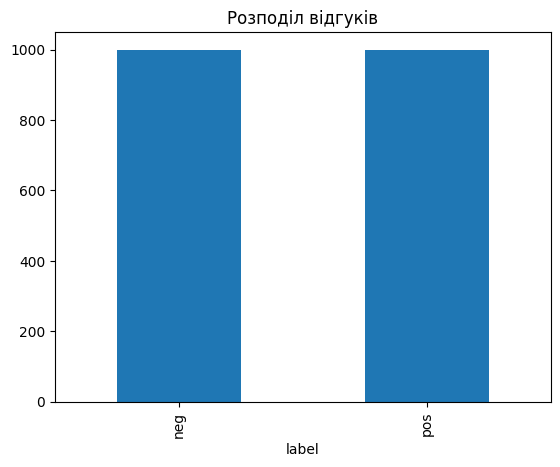

In [ ]:
# Подивимося кількість позитивних і негативних
df['label'].value_counts().plot(kind='bar', title='Розподіл відгуків')

#5. Перетворення тексту у числа

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])  # матриця "слів" → "числа"
y = df['label']

- `CountVectorizer` створює словник усіх слів і рахує, скільки разів кожне слово з’являється в тексті
- `X` — велика таблиця (рядки — відгуки, стовпці — слова, значення — кількість повторень)

In [ ]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 586)	1
  (0, 13012)	3
  (0, 4466)	8
  (0, 4935)	1
  (0, 11163)	1
  (0, 3406)	1
  (0, 16556)	1
  (0, 10320)	1
  (0, 1149)	1
  (0, 1839)	1
  (0, 18208)	2
  (0, 4463)	1
  (0, 25067)	1
  (0, 16392)	1
  (0, 22437)	1
  (0, 8709)	4
  (0, 13444)	4
  (0, 21893)	2
  (0, 7451)	1
  (0, 21038)	1
  (0, 14835)	1
  (0, 9929)	1
  (0, 22644)	1
  (0, 14782)	1
  (0, 16635)	1
  :	:
  (1999, 3415)	1
  (1999, 7004)	2
  (1999, 6579)	1
  (1999, 11456)	1
  (1999, 10529)	1
  (1999, 13732)	2
  (1999, 6247)	2
  (1999, 18045)	1
  (1999, 3610)	2
  (1999, 17951)	1
  (1999, 11309)	1
  (1999, 20957)	2
  (1999, 19637)	1
  (1999, 402)	1
  (1999, 1012)	1
  (1999, 9717)	1
  (1999, 1082)	2
  (1999, 2780)	1
  (1999, 6585)	1
  (1999, 11155)	3
  (1999, 6928)	1
  (1999, 3602)	1
  (1999, 444)	1
  (1999, 4642)	1
  (1999, 7198)	1
0       neg
1       pos
2       pos
3       neg
4       neg
       ... 
19

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
# from sklearn.linear_model import LogisticRegression


# Ділимо дані на навчальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Створюємо модель наївного байєсівського класифікатора
model = MultinomialNB()
# model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Прогноз на тестових даних
y_pred = model.predict(X_test)

#6. Оцінка якості

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8125


- `accuracy_score` — частка правильних відповідей
- `confusion_matrix` — скільки відгуків правильно класифіковано як позитивні/негативні

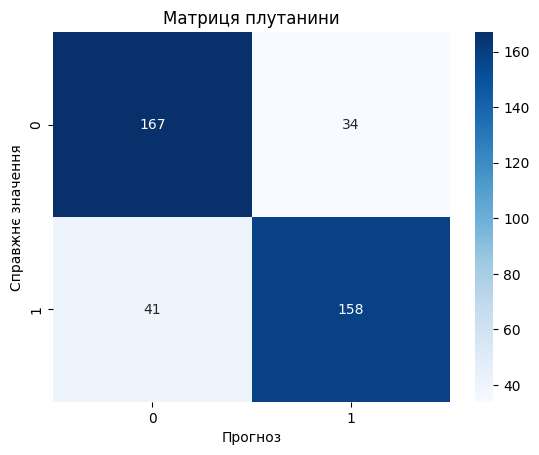

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Прогноз")
plt.ylabel("Справжнє значення")
plt.title("Матриця плутанини")
plt.show()

#7. Власна перевірка

Алгоритм перевірки:
1. Створюємо відгук
2. Очищаємо його
3. Перетворюємо в числа (через векторизатор)
4. Прогнозуємо результат

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def predict_review(text: str) -> str:
  cleaned = " ".join(clear_words(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model.predict(vec)[0]

In [ ]:
type(predict_review("text"))

str

In [ ]:
print(predict_review("The movie was boring"))
print(predict_review("Funny story! Thank`s"))
print("------")
print(predict_review("I like this movie!"))
print(predict_review("I'm sad that the movie is over"))
print(predict_review("The movie is terrible! Waste of time"))
print(predict_review("Norm"))
print(predict_review("Good"))
print(predict_review("Bad"))
print(predict_review("---------"))
print(predict_review("qwerty"))

neg
pos


| review | Actual | Naive Bayes (~79%) | Logistic Regression (~81%) |
| -- | -- | -- | -- |
| ` "The movie was boring" ` | neg | neg | neg |
| ` "Funny story! Thank's" ` | pos | pos | neg |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |

#8. Порівняння моделей: Naive Bayes vs Logistic Regression

- Точність обох моделей зазвичай 80–85%, але LogisticRegression часто трохи краща.
- У випадку простих текстових задач Naive Bayes — швидкий і ефективний, але логістична регресія краще працює на складніших даних.

## Multinomial Naive Bayes (MNB)

Naive Bayes — це сімейство моделей, що базуються на теоремі Байєса і працюють під припущенням, що всі ознаки незалежні одна від одної (наївне припущення).

Multinomial Naive Bayes — варіант, який найкраще підходить для тексту. Він працює з кількістю появ слів (а не просто фактом присутності).


📦 Як він працює:
- Вважає, що кожне слово в тексті має певну ймовірність з’явитись у позитивному або негативному тексті.
- Модель «вивчає» ці ймовірності з навчальних даних.
- Потім оцінює, до якого класу (позитив/негатив) з більшою ймовірністю належить новий текст.

✅ Коли використовувати:
- Коли дані — це тексти або відгуки.
- Коли важлива швидкість і простота.
- Якщо є багато текстових прикладів.

📊 Переваги:
- Дуже швидка та легка у використанні.
- Добре працює навіть з невеликою кількістю даних.
- Часто є «базовою» моделлю для тексту.

## Logistic Regression

Logistic Regression — це класична модель машинного навчання для бінарної класифікації (напр., "позитивний" чи "негативний").

Хоч назва «регресія», але модель виконує класифікацію, тобто вгадує клас.


📦 Як вона працює:
- Модель будує лінійну формулу на основі ознак (у нашому випадку — частотність слів).
- Потім використовує логістичну функцію (сигмоїду), щоб перетворити результат у ймовірність.
- Якщо ймовірність > 0.5 — класифікує як "позитивний", інакше — "негативний".

✅ Коли використовувати:
- Коли потрібно щось передбачити на основі даних.
- Коли хочеться трохи гнучкіша і точніша модель, ніж Naive Bayes.
- Коли важлива інтерпретація: Logistic Regression дозволяє побачити, які саме слова найбільше впливають на результат.

📊 Переваги:
- Часто точніша за Naive Bayes.
- Має багато налаштувань (регуляризація, кількість ітерацій).
- Працює з числовими, текстовими та іншими типами ознак.